# Instructions

For this assignment, you will use the dataset loaded below (or another appropriate dataset of your choice) and perform the following steps that were demonstrated in the practice Notebook.

**Do not delete any instructor-provided cells from this Notebook.** If you accidentally delete a cell, you can either undo the action or load a copy of the original assignment Notebook in a new browser tab and copy over the missing cells.

**You can and should add cells to this Notebook.** To add a markdown (text) cell, hover your cursor beneath the cell where you want to insert and click the "+Text" button. To add a Python (code) cell, click the "+Code" button.

Steps:
- Inspect the data
  - Display each column's data types
  - For any non-numerical columns, display all possible values
  - Create histograms of all the columns
  - In a markdown (text) cell, briefly write about your findings. Do you see anything that might cause problems for your model?
- Visualize the data
  - Create one or more plots of the data
    - Tip: Experiment with different types of plots
  - In a markdown (text) cell, briefly describe your findings. Did you find anything unexpected in the data?
- Prepare the data
  - Remove null values
    - Explain your reasoning for the approach you chose.
  - Encode categorical features
  - Scale the original numerical features
  - Combine all columns using a method of your choice
    - Recommended: Use `make_column_transformer`
- Train a Model
  - Instantiate a Linear Regression model
  - Fit the training data to the model
- Evaluate the Model
  - Predict labels **using the training data**
    - Use RMSE to see how well your model did on the training labels
  - Predict labels **using the testing data**
    - Use RMSE to see how well your model did on the testing labels
  - In a markdown (text) cell, briefly describe your findings. Based on how the model performed on the training and testing data, does it appear to have overfit or underfit the data?
- Submit your Notebook as a PDF.
  - Re-run all cells using "Run all" at the top.
  - From the File menu, select Print to download as a PDF.
  - Upload this PDF to Canvas.

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd

from sklearn import compose
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import tree

# Load the Dataset

This dataset contains records of individual medical insurance costs from people across the United States. Each record tracks both the actual amount billed by health insurance (the `charges` column) and personal information about the insured such as age, gender, body mass index (BMI), whether they smoke, how many children they have, and which region of the US they live in.

These factors are known to influence medical expenses and insurance premiums. The goal of analyzing this dataset is to understand how demographic and lifestyle details impact medical costs, and to develop models (such as linear regression) that can predict insurance charges for new individuals. This type of analysis is important for insurers, healthcare organizations, and individuals to estimate costs and plan for care.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/dkauffman-foothill/course-datasets/refs/heads/main/ml/insurance.csv")

# Inspect the Data

Display each column's data types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1338 non-null   int64  
 1   age         1338 non-null   int64  
 2   sex         1338 non-null   object 
 3   bmi         1338 non-null   float64
 4   children    1272 non-null   float64
 5   smoker      1325 non-null   object 
 6   region      1338 non-null   object 
 7   charges     1338 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 83.8+ KB


For any non-numerical columns, display all possible values.

In [ ]:
df["sex"].unique().tolist()

['female', 'male']

In [ ]:
df["smoker"].unique().tolist()

['yes', 'no', nan]

In [ ]:
df["region"].unique().tolist()

['southwest', 'southeast', 'northwest', 'northeast']

In [ ]:
IQR1 = df["bmi"].quantile(0.75) - df["bmi"].quantile(0.25)
IQR2 = df["age"].quantile(0.75) - df["age"].quantile(0.25)
IQR3 = df["charges"].quantile(0.75) - df["charges"].quantile(0.25)
IQR1, IQR2, IQR3

(np.float64(8.3975), np.float64(24.0), np.float64(11899.625365))

In [ ]:
print(df["bmi"].describe())

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64


In [ ]:
print(df["charges"].describe())

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


Create histograms of all the columns.

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'children'}>],
       [<Axes: title={'center': 'charges'}>, <Axes: >]], dtype=object)

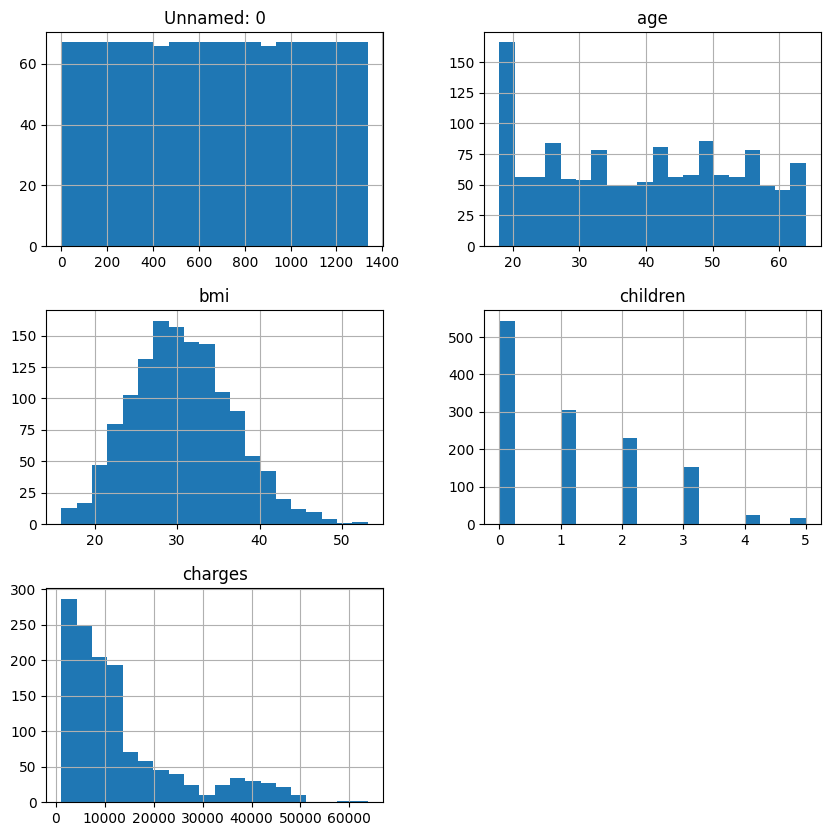

In [ ]:
df.hist(bins=20, figsize=(10, 10))

### Report Findings

Do you see anything that might cause problems for your model?



1.   There is an unnamed column of row number that is irrelevant.
2.   The charges are right skewed and so may impact the linear regression model which is senstive to outliers



## Visualize the Data

Create one or more plots of the data; experiment with different types of plots.

In [ ]:
import matplotlib.pyplot as plt


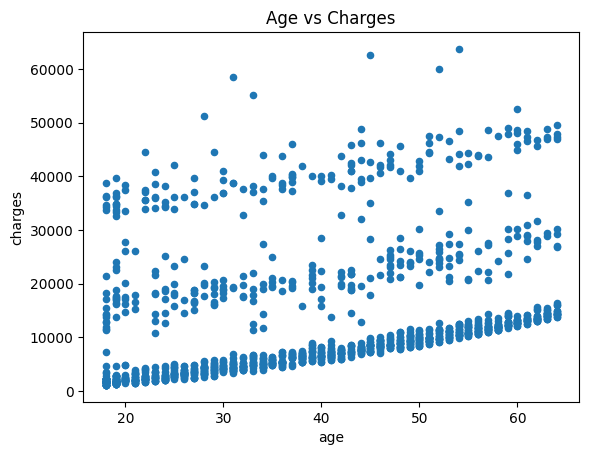

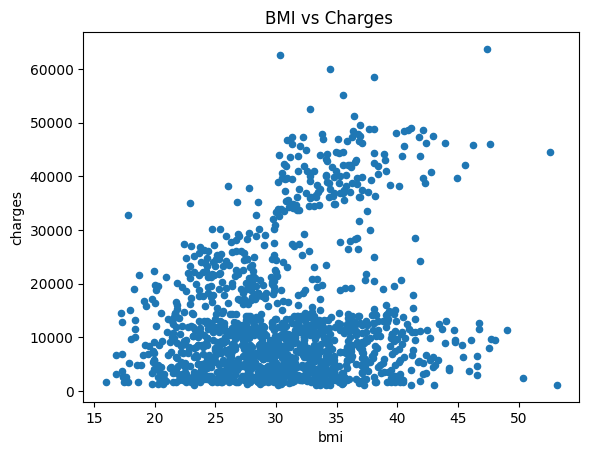

In [ ]:
# === age vs charges (does charges increase linearly with age?) ===
df.plot.scatter(
    x="age",
    y="charges",
    title="Age vs Charges"
)
plt.show()

# === bmi vs charges (often nonlinear or weakly linear) ===
df.plot.scatter(
    x="bmi",
    y="charges",
    title="BMI vs Charges "
)
plt.show()

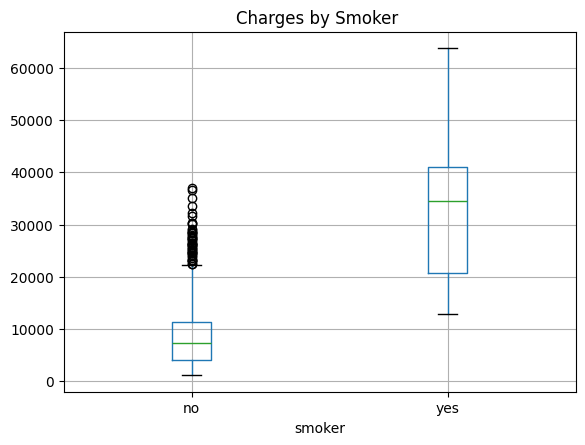

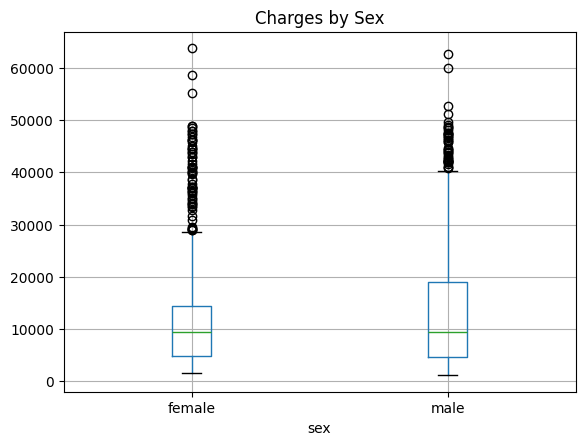

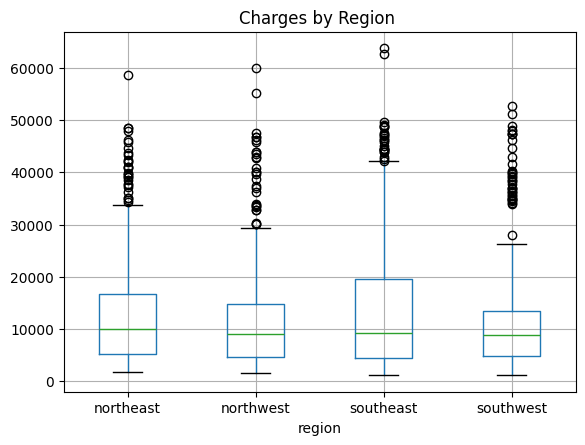

In [ ]:
# === smoker effect ===
df.boxplot(column="charges", by="smoker")
plt.title("Charges by Smoker ")
plt.suptitle("")
plt.show()

# === sex effect  ===
df.boxplot(column="charges", by="sex")
plt.title("Charges by Sex")
plt.suptitle("")
plt.show()

# === region effect  ===
df.boxplot(column="charges", by="region")
plt.title("Charges by Region ")
plt.suptitle("")
plt.show()

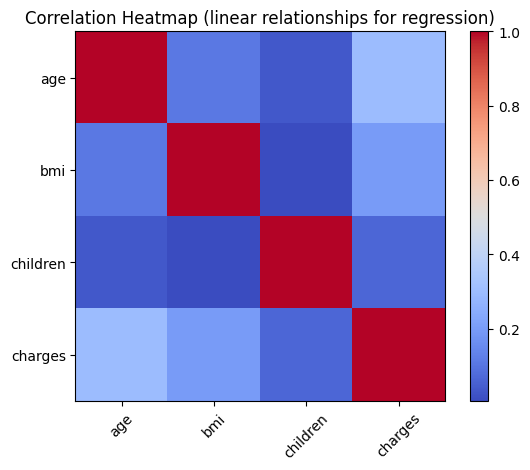

In [ ]:
corr = df[["age", "bmi", "children", "charges"]].corr()

plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap (linear relationships for regression)")
plt.show()

### Report Findings

Did you find anything unexpected in the data?




1.   For the numerical data, I wanted to see the linear relationship between the predictor vs target variable. I see that age and charges seem linear but bmi seems like weak linearity, which is unexpected to me.
2.   For categorical data, I used box plot, seems like only smoker vs non smokers shows a clear distinction of their median / mean values which suggest a strong predictor to charges, I had thought sex also will be strong predictor but data shows otherwise.
3. The correlation heatmap suggest that number of children may be more linearly correlated to charges amount.



# Prepare the Data

Remove any null values from the data. You can use the approach from the practice exercise, or you can use a different approach. Either way, justify your choice. You can create additional cells to show values such as the ratio of nulls cells.

In [ ]:
#porportion of null values
isnull = df.isnull().any(axis=1)
isnull_index = isnull[isnull].index
len(df.loc[isnull_index]) / len(df)

0.05829596412556054

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
age,0
sex,0
bmi,0
children,66
smoker,13
region,0
charges,0


Since the null data rows are only 5%, I'll remove the null data rows. Plus drop the first column since its just an ID column

In [ ]:
df= df.drop(isnull_index)

In [ ]:
df = df.drop("Unnamed: 0", axis=1)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Convert Categorical Features
You may use one-hot encoding (as in the practice exercise) or a different type of encoding.

In [ ]:
encoder = preprocessing.OneHotEncoder()
reg_features = df[["region"]]

encoded_features = encoder.fit_transform(reg_features)
encoded_features.toarray()

## Scale Numerical Features
You may use standardization (as in the practice exercise) or a different type of numerical scaling.

In [ ]:
numerical_only = df.drop(["sex", "smoker", "region"], axis=1)
preprocessing.StandardScaler().fit_transform(numerical_only)

# Split training and testing data

In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"].copy()
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)


## Combine Features
Recommended: Use `make_column_transformer` from the practice exercise.

In [ ]:
transformer = compose.make_column_transformer(
    (
        # Standardize numerical features.
        preprocessing.StandardScaler(),
        compose.make_column_selector(dtype_include=np.number)
    ),
    (
        # Encode non-numerical features.
        preprocessing.OneHotEncoder(),
        compose.make_column_selector(dtype_include=object)
    )
)

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

# Train and Evaluate a Model

Instantiate a Linear Regression model.

In [ ]:
lin_reg = linear_model.LinearRegression()


Fit the training data to the model.


In [ ]:
lin_reg.fit(X_train, y_train)

LinearRegression()

# Evaluate the Model

Predict labels using the training data. Use RMSE to see how well your model did on the training labels.


In [ ]:
y_pred = lin_reg.predict(X_train)
lin_rmse = metrics.root_mean_squared_error(y_train, y_pred)
lin_rmse

6057.963234528537

Predict labels using the testing data. Use RMSE to see how well your model did on the testing labels.


In [ ]:
y_pred = lin_reg.predict(X_test)

final_rmse = metrics.root_mean_squared_error(y_test, y_pred)
final_rmse

5621.684248000233

### Report Findings

Based on how the model performed on the training and testing data, does it appear to have overfit or underfit the data?

In [ ]:
abs(final_rmse - lin_rmse)/lin_rmse

0.07201743715472672

The model performed about as well on the test set as it did on the training set with a 7% difference in rmse.

The good news is that our model does not appear to have overfit to our training set. It learnt patterns that generalize to unseen examples.

And it didnt underfit the data - as we see the final rmse is less than the original rmse on the training data.